# Step 10: Fine-tune DINOv2-Large + UperNet (Depth-2, 19 classes)

Thin orchestration notebook for Databricks. All reusable logic lives in
`histological_image_analysis.training` (installed as a wheel on the cluster).

**Depth-2 mapping:** 18 brain structures at depth 2 in the Allen Brain ontology
(e.g., Cerebrum, Brain stem, Cerebellum, Thalamus, Hypothalamus, ...) plus background = 19 classes.
This is the intermediate granularity between coarse 6-class and full ~1,328-class mapping.

In [0]:
# Cell 0 — Install project wheel from DBFS
# The wheel is uploaded by `make deploy-wheel` and contains all reusable
# training pipeline code (ontology, slicer, dataset, training modules).

%pip install /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
dbutils.library.restartPython()

Processing /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Cell 1 — Configuration
# All environment-specific paths and hyperparameters live here.

import os
import mlflow

# ---------- MLflow setup ----------
os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

EXPERIMENT_NAME = "/Users/noel.nosse@grainger.com/histology-brain-segmentation"
try:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
except Exception:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
mlflow.set_experiment(experiment_id=experiment_id)
print(f"MLflow experiment: {EXPERIMENT_NAME} (ID: {experiment_id})")

# ---------- Databricks paths ----------
WORKSPACE_BASE = "/Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology"
ONTOLOGY_PATH = f"{WORKSPACE_BASE}/ontology/structure_graph_1.json"
ANNOTATION_10_PATH = f"{WORKSPACE_BASE}/ccfv3/annotation_10.nrrd"
# ara_nissl_10.nrrd exceeds workspace limit — lives on DBFS
NISSL_10_PATH = "/dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd"

# ---------- JFrog / HuggingFace model ----------
HF_ENDPOINT = os.environ.get(
    "HF_ENDPOINT",
    "https://graingerreadonly.jfrog.io/artifactory/api/huggingfaceml/huggingfaceml-remote",
)
MODEL_REPO_ID = "facebook/dinov2-large"
MODEL_CACHE_DIR = "/tmp/dinov2-large"

# ---------- Mapping ----------
MAPPING_TYPE = "depth2"
TARGET_DEPTH = 2

# ---------- Training hyperparameters ----------
HYPERPARAMS = {
    "mapping_type": MAPPING_TYPE,
    "target_depth": TARGET_DEPTH,
    "crop_size": 518,  # DINOv2 native resolution
    "batch_size": 8,
    "learning_rate": 1e-4,
    "num_epochs": 50,
    "freeze_backbone": True,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "split_strategy": "interleaved",
    "model": MODEL_REPO_ID,
    "dataset": "CCFv3 ara_nissl_10",
}

# Unpack for convenience (NUM_LABELS computed dynamically in Cell 3)
CROP_SIZE = HYPERPARAMS["crop_size"]
BATCH_SIZE = HYPERPARAMS["batch_size"]
LEARNING_RATE = HYPERPARAMS["learning_rate"]
NUM_EPOCHS = HYPERPARAMS["num_epochs"]
FREEZE_BACKBONE = HYPERPARAMS["freeze_backbone"]
SPLIT_STRATEGY = HYPERPARAMS["split_strategy"]

# ---------- Output ----------
OUTPUT_DIR = f"/tmp/checkpoints/{MAPPING_TYPE}"
FINAL_MODEL_DIR = f"/dbfs/FileStore/allen_brain_data/models/{MAPPING_TYPE}"

print(f"Ontology:       {ONTOLOGY_PATH}")
print(f"Nissl 10µm:     {NISSL_10_PATH}")
print(f"HF endpoint:    {HF_ENDPOINT}")
print(f"Mapping:        {MAPPING_TYPE} (depth {TARGET_DEPTH})")
print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Checkpoints:    {OUTPUT_DIR}")
print(f"Final model:    {FINAL_MODEL_DIR}")

MLflow experiment: /Users/noel.nosse@grainger.com/histology-brain-segmentation (ID: 1345391216675532)
Ontology:       /Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology/ontology/structure_graph_1.json
Nissl 10µm:     /dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd
HF endpoint:    https://graingerreadonly.jfrog.io/artifactory/api/huggingfaceml/huggingfaceml-remote
Mapping:        depth2 (depth 2)
Split strategy: interleaved
Checkpoints:    /tmp/checkpoints/depth2
Final model:    /dbfs/FileStore/allen_brain_data/models/depth2


In [0]:
# Cell 2 — Download model weights from JFrog Artifactory mirror
#
# Uses retry pattern per LESSONS_LEARNED.md — Artifactory can drop connections.
# etag_timeout=86400 avoids unnecessary HEAD requests.

import time
from huggingface_hub import snapshot_download

print(f"Downloading {MODEL_REPO_ID} from Artifactory...")
for attempt in range(1, 4):
    try:
        model_path = snapshot_download(
            repo_id=MODEL_REPO_ID,
            endpoint=HF_ENDPOINT,
            etag_timeout=86400,
            cache_dir=MODEL_CACHE_DIR,
        )
        break
    except Exception as e:
        if attempt < 3:
            wait = 2 ** attempt
            print(f"  Attempt {attempt} failed ({e.__class__.__name__}), retrying in {wait}s...")
            time.sleep(wait)
        else:
            raise

print(f"Model downloaded to: {model_path}")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

(…)a6652ed6f75ec47/preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

(…)d21ea90829a6652ed6f75ec47/.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

(…)496e6d21ea90829a6652ed6f75ec47/README.md:   0%|          | 0.00/3.03k [00:00<?, ?B/s]

(…)6e6d21ea90829a6652ed6f75ec47/config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

(…)ea90829a6652ed6f75ec47/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

(…)ea90829a6652ed6f75ec47/pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Model downloaded to: /tmp/dinov2-large/models--facebook--dinov2-large/snapshots/a18992645e496e6d21ea90829a6652ed6f75ec47


In [0]:
# Cell 3 — Build training and validation datasets
#
# Pipeline: OntologyMapper → CCFv3Slicer → BrainSegmentationDataset
#
# Uses depth-2 mapping (18 brain structures + background = 19 classes)
# and INTERLEAVED split strategy.

from collections import Counter
from histological_image_analysis.ontology import OntologyMapper
from histological_image_analysis.ccfv3_slicer import CCFv3Slicer
from histological_image_analysis.dataset import BrainSegmentationDataset

# 1. Load ontology and build depth-2 mapping
mapper = OntologyMapper(ONTOLOGY_PATH)
mapping = mapper.build_depth_mapping(target_depth=TARGET_DEPTH)
NUM_LABELS = mapper.get_num_labels(mapping)
class_names = mapper.get_class_names(mapping)
HYPERPARAMS["num_labels"] = NUM_LABELS
print(f"Depth-{TARGET_DEPTH} classes ({NUM_LABELS}): {class_names}")

# 2. Load CCFv3 volumes (10µm Nissl + annotations)
slicer = CCFv3Slicer(
    image_path=NISSL_10_PATH,
    annotation_path=ANNOTATION_10_PATH,
    ontology_mapper=mapper,
)
slicer.load_volumes()
print(f"Loaded {slicer.num_slices} coronal slices")

# 3. Interleaved train/val/test split
splits = slicer.get_split_indices(
    train_frac=0.8, val_frac=0.1, split_strategy=SPLIT_STRATEGY,
)
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

# 4. Create datasets
train_ds = BrainSegmentationDataset(
    slicer=slicer, split="train", mapping=mapping,
    crop_size=CROP_SIZE, augment=True, split_strategy=SPLIT_STRATEGY,
)
val_ds = BrainSegmentationDataset(
    slicer=slicer, split="val", mapping=mapping,
    crop_size=CROP_SIZE, augment=False, split_strategy=SPLIT_STRATEGY,
)
print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

# Sanity check: inspect one sample
sample = train_ds[0]
print(f"pixel_values: {sample['pixel_values'].shape}, labels: {sample['labels'].shape}")

# Class distribution check — verify classes present in val
val_class_counts = Counter()
for i in range(len(val_ds)):
    labels = val_ds[i]["labels"].numpy()
    for cls in range(NUM_LABELS):
        val_class_counts[cls] += int((labels == cls).sum())
print(f"\nVal class distribution:")
for cls in range(NUM_LABELS):
    name = class_names[cls] if cls < len(class_names) else f"class_{cls}"
    count = val_class_counts[cls]
    print(f"  {cls} ({name}): {count:,} pixels")

Depth-2 classes (19): ['Background', 'lateral ventricle', 'interventricular foramen', 'third ventricle', 'cerebral aqueduct', 'fourth ventricle', 'central canal, spinal cord/medulla', 'Brain stem', 'Cerebellum', 'Cerebrum', 'Interpeduncular fossa', 'cerebellum related fiber tracts', 'cranial nerves', 'lateral forebrain bundle system', 'medial forebrain bundle system', 'extrapyramidal fiber systems', 'grooves of the cerebral cortex', 'grooves of the cerebellar cortex', 'supra-callosal cerebral white matter']
Loaded 1320 coronal slices
Train: 1016 | Val: 127 | Test: 127
Train samples: 1016 | Val samples: 127
pixel_values: torch.Size([3, 518, 518]), labels: torch.Size([518, 518])

Val class distribution:
  0 (Background): 4,640,118 pixels
  1 (lateral ventricle): 288,064 pixels
  2 (interventricular foramen): 0 pixels
  3 (third ventricle): 82,080 pixels
  4 (cerebral aqueduct): 42,606 pixels
  5 (fourth ventricle): 79,570 pixels
  6 (central canal, spinal cord/medulla): 44 pixels
  7 (Br

In [0]:
# Cell 4 — Create model
#
# Frozen backbone, head-only training.
# Forward-pass sanity check included.

import torch
from histological_image_analysis.training import create_model

model = create_model(
    num_labels=NUM_LABELS,
    freeze_backbone=FREEZE_BACKBONE,
    pretrained_backbone_path=model_path,
)

# Sanity check — single forward pass
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, CROP_SIZE, CROP_SIZE)
    if torch.cuda.is_available():
        model = model.cuda()
        dummy = dummy.cuda()
    out = model(pixel_values=dummy)
    print(f"Logits shape: {out.logits.shape}")
    print(f"Expected: (1, {NUM_LABELS}, {CROP_SIZE}, {CROP_SIZE})")
    assert out.logits.shape == (1, NUM_LABELS, CROP_SIZE, CROP_SIZE)
    model = model.cpu()  # Free GPU for training
print("Forward pass OK")

2026-03-10 23:30:02.186395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773185402.202467    2655 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773185402.207430    2655 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773185402.221390    2655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773185402.221402    2655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773185402.221405    2655 computation_placer.cc:177] computation placer alr

[2026-03-10 23:30:08,964] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


df: /root/.triton/autotune: No such file or directory
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Logits shape: torch.Size([1, 19, 518, 518])
Expected: (1, 19, 518, 518)
Forward pass OK


In [0]:
# Cell 5 — Train
#
# Single MLflow run spans training + eval + export (per LESSONS_LEARNED.md).
# HF Trainer's MLflowCallback logs per-epoch metrics automatically.

from datetime import datetime
from histological_image_analysis.training import create_trainer, get_training_args

mlflow.start_run(run_name=f"{MAPPING_TYPE}-{NUM_LABELS}class-{datetime.now().strftime('%Y%m%d-%H%M')}")
mlflow.log_params(HYPERPARAMS)

training_args = get_training_args(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    fp16=torch.cuda.is_available(),
    report_to="mlflow",
)

trainer = create_trainer(
    model=model,
    training_args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    num_labels=NUM_LABELS,
)

trainer.train()

2026/03/10 23:30:19 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/10 23:30:19 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
[rank0]:[W310 23:30:21.511038440 reducer.cpp:1430] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())


Epoch,Training Loss,Validation Loss,Mean Iou,Overall Accuracy,Iou Class 0,Iou Class 1,Iou Class 2,Iou Class 3,Iou Class 4,Iou Class 5,Iou Class 6,Iou Class 7,Iou Class 8,Iou Class 9,Iou Class 10,Iou Class 11,Iou Class 12,Iou Class 13,Iou Class 14,Iou Class 15,Iou Class 16,Iou Class 17,Iou Class 18
1,1.911300,1.990529,0.189173,0.790206,0.745184,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.729256,0.637448,0.723689,nan,0.000000,0.001961,0.000061,0.000000,0.000000,nan,nan,0.000000
2,1.011800,1.134455,0.287488,0.861646,0.781862,0.280035,nan,0.000000,0.000000,0.000000,0.000000,0.813819,0.814564,0.848821,nan,0.255068,0.183381,0.269547,0.065220,0.000000,nan,nan,0.000000
3,0.664500,0.767656,0.406157,0.890372,0.806918,0.513657,nan,0.266926,0.428273,0.074402,0.000000,0.874805,0.836962,0.883668,nan,0.386376,0.314141,0.441522,0.264712,0.000000,nan,nan,0.000000
4,0.525700,0.593678,0.453343,0.899323,0.827424,0.573844,nan,0.271074,0.497785,0.266526,0.000000,0.882536,0.843733,0.900793,nan,0.464514,0.387296,0.518554,0.366070,0.000000,nan,nan,0.000000
5,0.397800,0.483517,0.487912,0.907425,0.841304,0.643404,nan,0.407654,0.532738,0.303078,0.000000,0.881714,0.869180,0.899250,nan,0.533548,0.377295,0.550853,0.360380,0.002384,nan,nan,0.115901
6,0.363700,0.440345,0.525732,0.911358,0.828978,0.662552,nan,0.454174,0.669060,0.321399,0.000000,0.893445,0.872462,0.907115,nan,0.541888,0.423925,0.592793,0.448384,0.004187,nan,nan,0.265620
7,0.325200,0.395052,0.540354,0.918460,0.841091,0.676499,nan,0.488951,0.599947,0.364119,0.000000,0.903521,0.887251,0.919594,nan,0.569792,0.438962,0.584742,0.468430,0.000000,nan,nan,0.362410
8,0.310400,0.363774,0.557521,0.922989,0.846413,0.707456,nan,0.443841,0.657008,0.394836,0.000000,0.909369,0.889638,0.923924,nan,0.580951,0.467534,0.621733,0.489124,0.035357,nan,nan,0.395635
9,0.271400,0.341072,0.570845,0.926543,0.850171,0.699894,nan,0.508469,0.729798,0.403977,0.000000,0.916214,0.893053,0.928114,nan,0.612100,0.469193,0.630044,0.500336,0.017269,nan,nan,0.404048
10,0.268400,0.318269,0.578675,0.930686,0.868077,0.723534,nan,0.501631,0.643866,0.420190,0.000000,0.917653,0.896771,0.934075,nan,0.601468,0.505269,0.659731,0.491514,0.158708,nan,nan,0.357640


TrainOutput(global_step=6350, training_loss=0.30545543178798645, metrics={'train_runtime': 1523.4932, 'train_samples_per_second': 33.344, 'train_steps_per_second': 4.168, 'total_flos': 8.368982316592136e+19, 'train_loss': 0.30545543178798645, 'epoch': 50.0})

Evaluation results:
  epoch: 50.0000
  eval_iou_class_0: 0.9119
  eval_iou_class_1: 0.8087
  eval_iou_class_10: nan
  eval_iou_class_11: 0.7258
  eval_iou_class_12: 0.6462
  eval_iou_class_13: 0.7712
  eval_iou_class_14: 0.6499
  eval_iou_class_15: 0.4443
  eval_iou_class_16: nan
  eval_iou_class_17: nan
  eval_iou_class_18: 0.5815
  eval_iou_class_2: nan
  eval_iou_class_3: 0.6946
  eval_iou_class_4: 0.7953
  eval_iou_class_5: 0.5787
  eval_iou_class_6: 0.0000
  eval_iou_class_7: 0.9447
  eval_iou_class_8: 0.9301
  eval_iou_class_9: 0.9580
  eval_loss: 0.1939
  eval_mean_iou: 0.6961
  eval_overall_accuracy: 0.9548
  eval_runtime: 4.3526
  eval_samples_per_second: 29.1780
  eval_steps_per_second: 3.6760

Per-class IoU (depth2, 19 classes):
    0 (Background                    ): 0.9119
    1 (lateral ventricle             ): 0.8087
    2 (interventricular foramen      ): nan
    3 (third ventricle               ): 0.6946
    4 (cerebral aqueduct             ): 0.7953
    5 (fourth vent

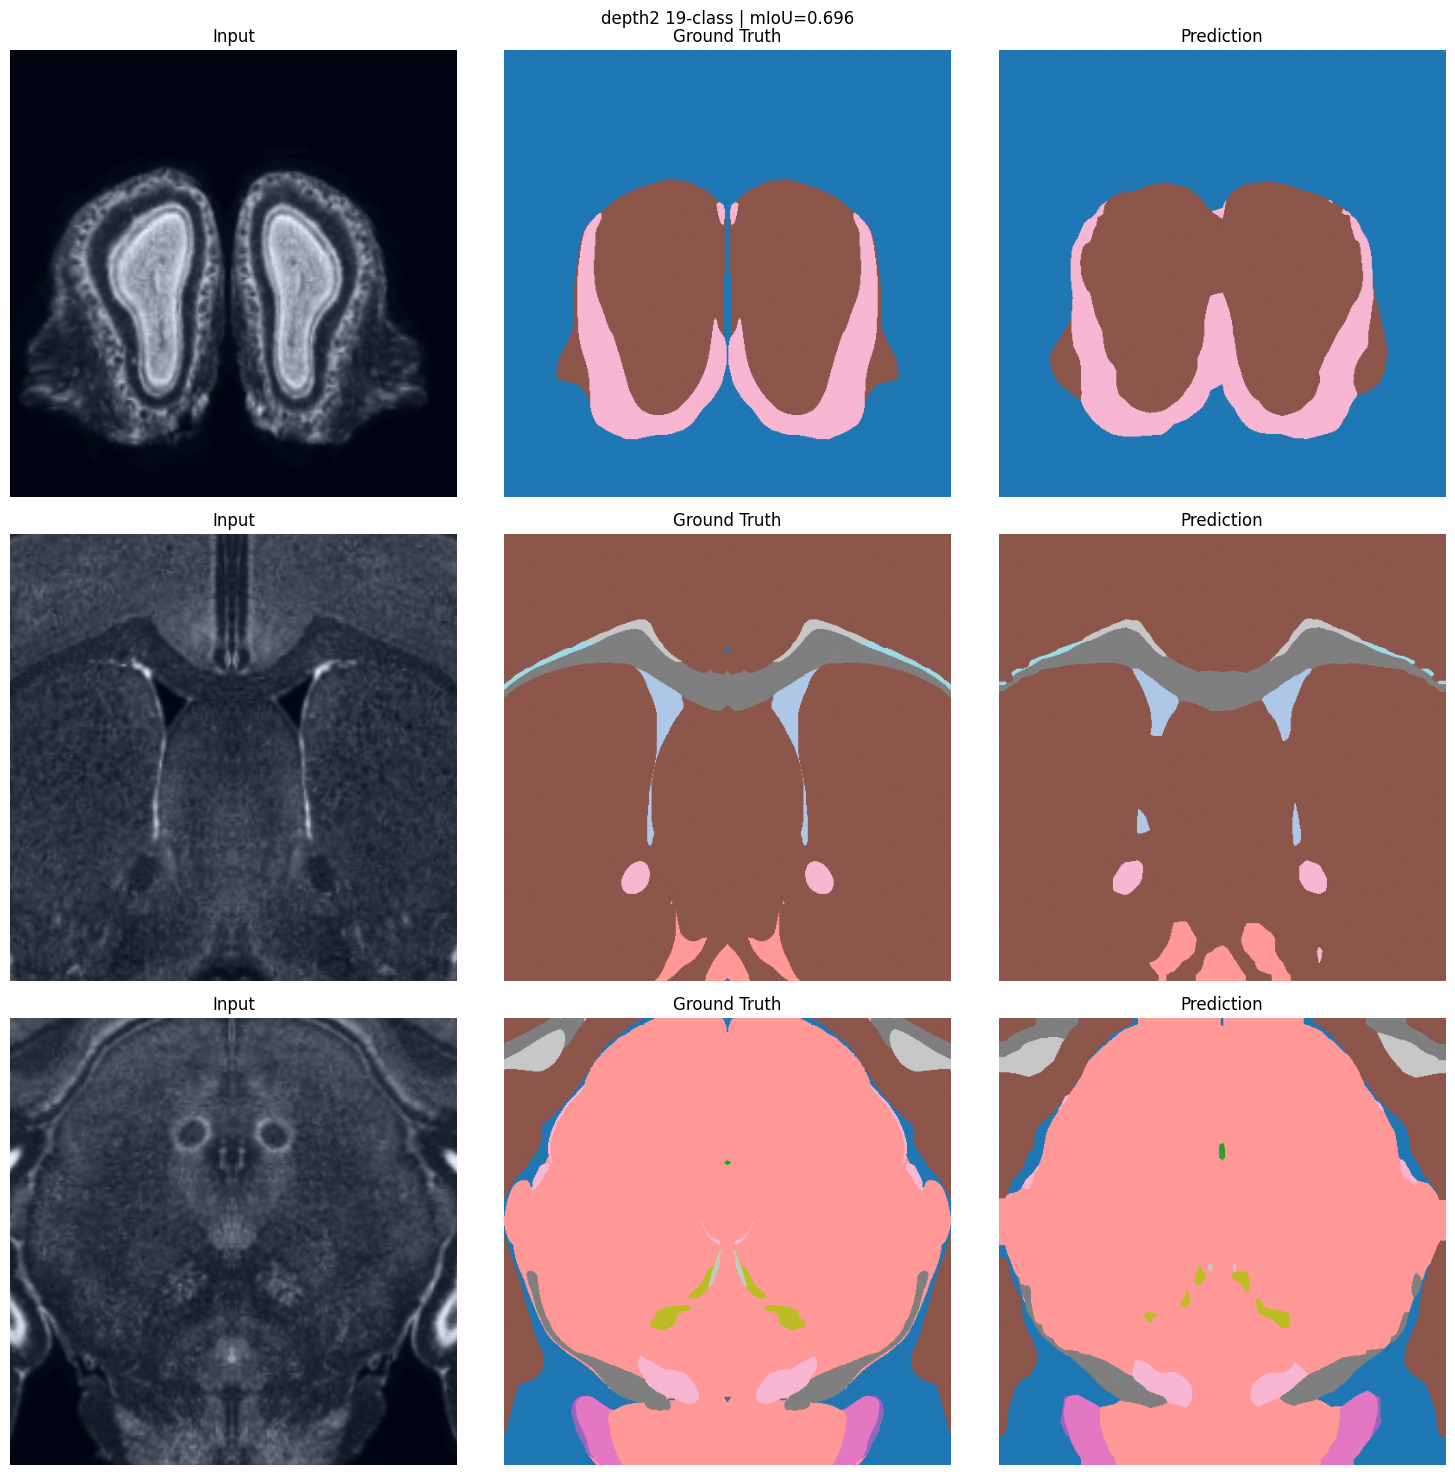

In [0]:
# Cell 6 — Evaluate + Visualize
#
# Logs to the same active MLflow run opened in Cell 5.
# Uses get_class_names() for per-class IoU reporting.

import matplotlib.pyplot as plt
import numpy as np

# Run evaluation
eval_results = trainer.evaluate()
print("Evaluation results:")
for k, v in sorted(eval_results.items()):
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

# Log final eval metrics explicitly
mlflow.log_metrics({
    "final_mean_iou": eval_results.get("eval_mean_iou", 0.0),
    "final_overall_accuracy": eval_results.get("eval_overall_accuracy", 0.0),
})

# Per-class IoU report
print(f"\nPer-class IoU ({MAPPING_TYPE}, {NUM_LABELS} classes):")
for cls in range(NUM_LABELS):
    iou_key = f"eval_iou_class_{cls}"
    iou = eval_results.get(iou_key, float('nan'))
    name = class_names[cls] if cls < len(class_names) else f"class_{cls}"
    print(f"  {cls:3d} ({name:30s}): {iou:.4f}")

# Visualize predictions vs ground truth on a few val samples
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    sample = val_ds[i * (len(val_ds) // 3)]
    pixel_values = sample["pixel_values"].unsqueeze(0)
    labels = sample["labels"].numpy()

    with torch.no_grad():
        if torch.cuda.is_available():
            pixel_values = pixel_values.cuda()
        logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Denormalize image for display
    img = sample["pixel_values"].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input")
    axes[i, 1].imshow(labels, cmap="tab20", vmin=0, vmax=NUM_LABELS - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(preds, cmap="tab20", vmin=0, vmax=NUM_LABELS - 1)
    axes[i, 2].set_title("Prediction")

for ax in axes.ravel():
    ax.axis("off")

plt.suptitle(f"{MAPPING_TYPE} {NUM_LABELS}-class | mIoU={eval_results.get('eval_mean_iou', 0):.3f}")
plt.tight_layout()
plt.show()

In [0]:
# Cell 7 — Save final model + close MLflow run

import os

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
trainer.save_model(FINAL_MODEL_DIR)
print(f"Model saved to: {FINAL_MODEL_DIR}")

# Close the MLflow run opened in Cell 5.
# Per LESSONS_LEARNED.md: HF Trainer's MLflowCallback can leave runs open.
mlflow.end_run()
print("MLflow run closed.")

Model saved to: /dbfs/FileStore/allen_brain_data/models/depth2


2026/03/10 23:55:55 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/10 23:55:55 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


MLflow run closed.
